In [101]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import  scipy
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split

In [86]:
DATA_DIR = Path("../data")

In [56]:
product_df = pd.read_csv(
    DATA_DIR / "PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021(Product Level Data).csv",
    encoding="latin1"
)


In [57]:
print(f"Product Dataset:  {product_df.shape}")


Product Dataset:  (866, 25)


In [58]:
product_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   *PCF-ID                                    866 non-null    str    
 1   Year of reporting                          866 non-null    int64  
 2   *Stage-level CO2e available                866 non-null    str    
 3   Product name (and functional unit)         866 non-null    str    
 4   Product detail                             856 non-null    str    
 5   Company                                    866 non-null    str    
 6   Country (where company is incorporated)    866 non-null    str    
 7   Company's GICS Industry Group              866 non-null    str    
 8   Company's GICS Industry                    866 non-null    str    
 9   *Company's sector                          866 non-null    str    
 10  Product weight (kg)                  

In [59]:



product_data_summary = pd.DataFrame({
    'Source_Table': 'product_df',
    'Column_Name': product_df.columns,
    'Non_Null_Count': product_df.notnull().sum().values,
    'Unique_Values': product_df.nunique().values,
    'Data_Type': product_df.dtypes.values
})







display(product_data_summary)

,Source_Table,Column_Name,Non_Null_Count,Unique_Values,Data_Type
0,product_df,*PCF-ID,866,866,str
1,product_df,Year of reporting,866,5,int64
2,product_df,*Stage-level CO2e available,866,2,str
3,product_df,Product name (and functional unit),866,672,str
4,product_df,Product detail,856,496,str
5,product_df,Company,866,145,str
6,product_df,Country (where company is incorporated),866,28,str
7,product_df,Company's GICS Industry Group,866,30,str
8,product_df,Company's GICS Industry,866,35,str
9,product_df,*Company's sector,866,8,str


In [60]:
product_df['Year of reporting'].value_counts().sort_index()

Year of reporting
2013    179
2014    190
2015    217
2016    218
2017     62
Name: count, dtype: int64

Year was retained as a numerical feature because it represents an ordered temporal variable. Preserving its integer values allows machine learning algorithms to learn potential temporal trends without introducing unnecessary feature transformations.

In [61]:
product_df['*Stage-level CO2e available'].value_counts()

*Stage-level CO2e available
No     445
Yes    421
Name: count, dtype: int64

In [62]:
product_df['Country (where company is incorporated)'].value_counts()

Country (where company is incorporated)
USA               305
Japan             110
Germany            67
Taiwan             60
Finland            35
Netherlands        35
United Kingdom     32
Switzerland        28
Sweden             26
Italy              23
South Korea        22
France             20
Brazil             17
India              16
Spain              13
South Africa       11
Belgium             8
China               6
Canada              6
Ireland             6
Australia           6
Malaysia            4
Chile               3
Colombia            2
Luxembourg          2
Lithuania           1
Indonesia           1
Greece              1
Name: count, dtype: int64

### Drop replace by Region

In [63]:
product_df["Company's GICS Industry Group"].value_counts()

Company's GICS Industry Group
Technology Hardware & Equipment                                         195
Materials                                                               161
Food, Beverage & Tobacco                                                101
Automobiles & Components                                                 73
Consumer Durables & Apparel                                              52
Commercial & Professional Services                                       42
Capital Goods                                                            33
Chemicals                                                                29
Software & Services                                                      27
Food & Staples Retailing                                                 24
Textiles, Apparel, Footwear and Luxury Goods                             16
Media                                                                    15
Food & Beverage Processing                                

In [64]:
product_df["Company's GICS Industry"].value_counts()

Company's GICS Industry
Not used for 2015 reporting                       215
Chemicals                                          82
Computers & Peripherals                            70
Beverages                                          70
Electronic Equipment, Instruments & Components     47
Commercial Services & Supplies                     42
Auto Components                                    38
Paper & Forest Products                            34
Textiles, Apparel & Luxury Goods                   31
Food Products                                      30
Containers & Packaging                             28
Office Electronics                                 24
Household Durables                                 21
Metals & Mining                                    16
Software                                           14
Electrical Equipment                               14
Food & Staples Retailing                           14
Automobiles                                        13
Medi

"Provides reliable granular industry classification (30 well-defined groups) without structural missingness. Captures mid-level manufacturing and operational carbon baselines."

In [65]:
product_df["*Company's sector"].value_counts()

*Company's sector
Computer, IT & telecom                  253
Food & Beverage                         139
Home durables, textiles, & equipment    122
Chemicals                               116
Automobiles & components                 75
Construction & commercial materials      67
Comm. equipm. & capital goods            56
Packaging for consumer goods             38
Name: count, dtype: int64

Highly dense, zero-missingness high-level economic categorization (8 primary sectors). Serves as an ideal top-tier categorical driver for baseline PCF differentiation.

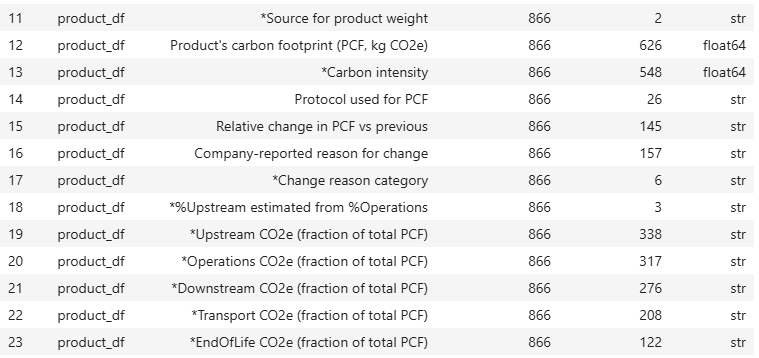

In [66]:
product_df['Protocol used for PCF'].value_counts()

Protocol used for PCF
ISO                            353
GHGP                           183
Not reported                   179
PAS2050                         73
TRACI 2.1                       20
Paper Profile                   12
MIT PAIA                         9
ILCD Handbook                    8
M. Env. Japan                    4
EcoLeaf                          4
Japan CFP                        2
EICC Tool                        2
EUPEF                            2
CEPI                             2
Carbon Labeling Certificate      2
WBCSD                            1
French PEF                       1
FEFCO                            1
Traci 2.1                        1
JRM Assoc.                       1
Korea CL Guide                   1
JEC/BIOGRACE                     1
CFP Japan                        1
EPD                              1
Bilan Carbone                    1
M. Env. Japan v2.2               1
Name: count, dtype: int64

In [67]:
product_df['*Change reason category'].value_counts()

*Change reason category
N/a (no %change reported)                                 482
Product carbon efficiency changed                         166
N/a (no previous data available)                          134
No specific reason reported                                38
Model and/or parameters changed (but not product)          25
Model/parameters AND product carbon efficiency changed     21
Name: count, dtype: int64

Dropped (*Change reason category): Over 75.5% of the records contain non-informative or missing entries (N/a (no %change reported), N/a (no previous data available), and No specific reason reported).

In [68]:
product_df['*%Upstream estimated from %Operations'].value_counts()

*%Upstream estimated from %Operations
N/a (product with insufficient stage-level data)    445
No                                                  317
Yes                                                 104
Name: count, dtype: int64

"Dropped (*%Upstream estimated from %Operations): Over 51.4% of the dataset contains missing or uninformative values (N/a (product with insufficient stage-level data)). Additionally, this feature represents an estimation flag used during data compilation rather than an intrinsic physical or supply-chain attribute of the product. Structural stage availability is already captured via engineered LCA stage metadata."

In [73]:
product_df = product_df.rename(columns={
    "Year of reporting": "Year",

    "Country (where company is incorporated)": "Country",
    "Company's GICS Industry": "Industry",
    "*Company's sector": "Sector",
    "Product weight (kg)": "Product_Weight",
    "Product's carbon footprint (PCF, kg CO2e)": "PCF",

    "Protocol used for PCF": "PCF_Protocol",

    
    "*Stage-level CO2e available": "Stage_Level_CO2e_Available",
   
})

In [74]:

productclean_df = product_df[[
    "Year",
    "Stage_Level_CO2e_Available",
    "Country",
    "Industry",
    "Sector",
    "Product_Weight",
    "PCF_Protocol",
    "PCF"
]].copy()

In [75]:
productclean_df.head()

,Year,Stage_Level_CO2e_Available,Country,Industry,Sector,Product_Weight,PCF_Protocol,PCF
0,2014,Yes,USA,Food Products,Food & Beverage,0.7485,Not reported,2.00
1,2015,Yes,USA,Not used for 2015 reporting,Food & Beverage,0.7485,Not reported,2.00
2,2013,Yes,USA,Building Products,Comm. equipm. & capital goods,20.6800,Not reported,72.54
3,2017,Yes,Japan,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",110.0000,ISO,1488.00
4,2017,Yes,Japan,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",110.0000,ISO,1818.00


In [78]:
productclean_df.to_csv(
    "/workspaces/pcf-quality-framework/BEACON-PCF/data/productclean_df.csv",
    index=False
)

In [79]:
missing = productclean_df.isnull().sum().sort_values(ascending=False)
missing

Year                          0
Stage_Level_CO2e_Available    0
Country                       0
Industry                      0
Sector                        0
Product_Weight                0
PCF_Protocol                  0
PCF                           0
dtype: int64

In [ ]:
productclean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        866 non-null    int64  
 1   Stage_Level_CO2e_Available  866 non-null    str    
 2   Country                     866 non-null    str    
 3   Industry                    866 non-null    str    
 4   Sector                      866 non-null    str    
 5   Product_Weight              866 non-null    float64
 6   PCF_Protocol                866 non-null    str    
 7   PCF                         866 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 54.3 KB


In [98]:
X = productclean_df.drop("PCF", axis=1)
y = productclean_df["PCF"]

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (692, 7)
X_test : (174, 7)
y_train: (692,)
y_test : (174,)


/tmp/ipykernel_2578/2514995624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_cleanf1[col].dropna(), vert=False)


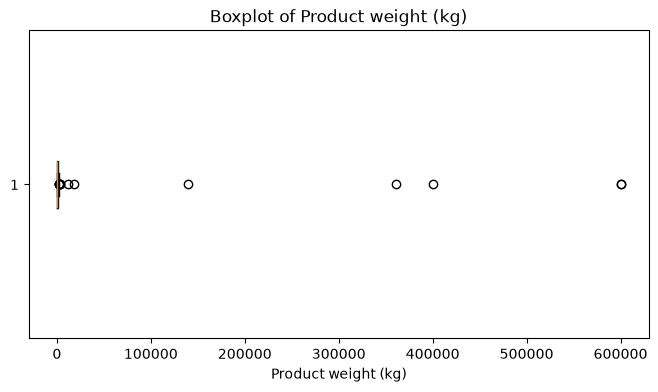

/tmp/ipykernel_2578/2514995624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_cleanf1[col].dropna(), vert=False)


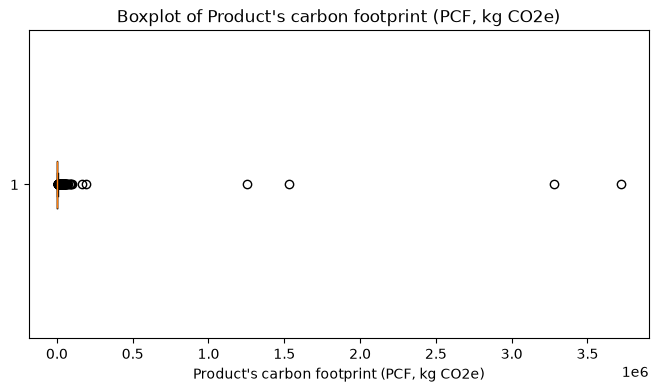

/tmp/ipykernel_2578/2514995624.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(product_cleanf1[col].dropna(), vert=False)


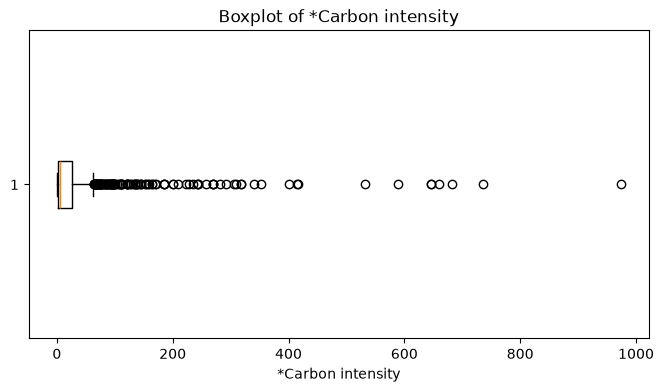

In [ ]:
outlier_cols = [
    "Product weight (kg)",
    "Product's carbon footprint (PCF, kg CO2e)",
    "*Carbon intensity"
]

for col in outlier_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(product_cleanf1[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [93]:
outlier_cols = [
    "Product_Weight",
    "PCF",
]

In [95]:
productclean_df[outlier_cols].describe()

,Product_Weight,PCF
count,866.000000,8.660000e+02
mean,2806.548993,1.581525e+04
std,34405.725655,1.813733e+05
min,0.001270,4.000000e-04
25%,1.000000,7.000000e+00
50%,15.899207,1.111000e+02
75%,1000.000000,1.600000e+03
max,600000.000000,3.718044e+06


/tmp/ipykernel_8979/531155541.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(productclean_df[col].dropna(), vert=False)


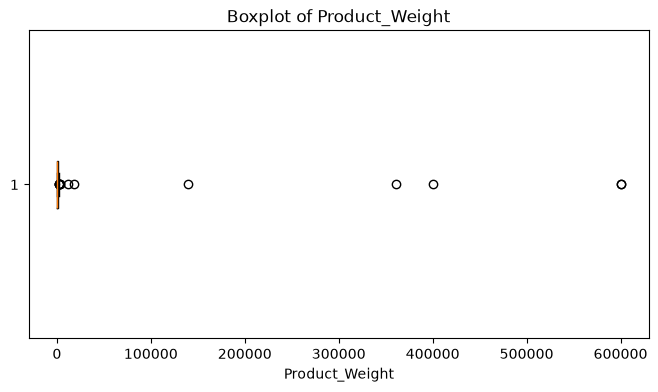

/tmp/ipykernel_8979/531155541.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(productclean_df[col].dropna(), vert=False)


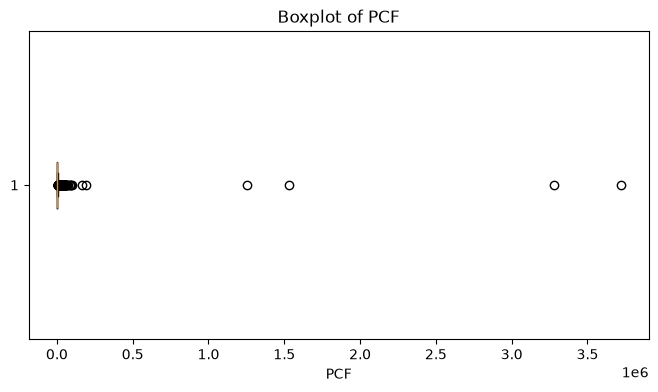

In [96]:


for col in outlier_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(productclean_df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [97]:
def outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((series < lower) | (series > upper)).sum()


for col in outlier_cols:
    print(f"{col}: {outlier_count(productclean_df[col])} outliers")

Product_Weight: 13 outliers
PCF: 122 outliers
